In [1]:
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
train_dir="/content/drive/MyDrive/zzzzzzzz/60 tấm selfies - sáng T2"
img_width, img_height = 128, 128
batch_size = 32

# Tăng cường dữ liệu dành cho huấn luyện mô hình
train_datagen = ImageDataGenerator(
    rescale=1.0/255, # Normalize pixel values
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode="nearest"
)

In [2]:
# Tải dữ liệu huấn luyện
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode="categorical"
)

# XÂY DỰNG MÔ HÌNH CNN
model = Sequential([
    Conv2D(32, (3,3), activation="relu",
           input_shape=(img_width, img_height, 3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation="relu"),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation="relu"),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(128, activation="relu"),

    Dropout(0.5),  # Reduce overfitting

    Dense(22, activation="softmax")  # 5 categories
])

# Compile model
model.compile(
    optimizer='rmsprop',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

Found 1293 images belonging to 22 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [3]:
# Biên dịch mô hình
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# Tóm tắt cấu hình của mô hình
model.summary()




Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 22)             │         2,838 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,307,478 (12.62 MB)

 Trainable params: 3,307,478 (12.62 MB)

 Non-trainable params: 0 (0.00 B)

In [4]:
# HUẤN LUYỆN MÔ HÌNH CNN
epochs = 30

history = model.fit(
    train_generator,
    epochs=epochs
)

Epoch 1/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 66s 2s/step - accuracy: 0.1052 - loss: 3.0090
Epoch 2/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 66s 2s/step - accuracy: 0.2691 - loss: 2.4834
Epoch 3/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 62s 2s/step - accuracy: 0.4084 - loss: 1.9513
Epoch 4/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 66s 2s/step - accuracy: 0.5205 - loss: 1.6016
Epoch 5/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 66s 2s/step - accuracy: 0.5940 - loss: 1.3375
Epoch 6/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 62s 1s/step - accuracy: 0.6458 - loss: 1.1687
Epoch 7/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 64s 2s/step - accuracy: 0.6759 - loss: 1.0983
Epoch 8/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 64s 2s/step - accuracy: 0.6991 - loss: 1.0443
Epoch 9/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 64s 2s/step - accuracy: 0.7185 - loss: 0.9529
Epoch 10/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 63s 2s/step - accuracy: 0.7525 - loss: 0.8143
Epoch 11/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 61s 1s/step - accuracy: 0.7293 - loss: 0.9058
Epoch 12/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 61s 1s/step - accuracy: 0.7417 - lo

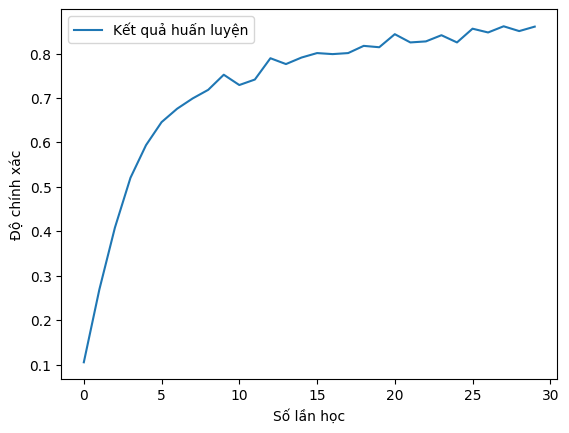

In [5]:

# ĐÁNH GIÁ KẾT QUẢ MÔ HÌNH
plt.plot(history.history['accuracy'],
         label="Kết quả huấn luyện")

plt.xlabel("Số lần học")
plt.ylabel("Độ chính xác")

plt.legend()
plt.show()

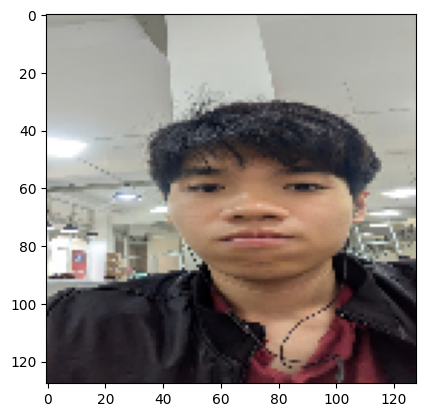

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
Người tiên đoán: Đoàn Hùng


In [11]:
# Tải và tiền xử lý ảnh kiểm tra
from keras.utils import load_img
import numpy as np

path = "/content/z7880197404973_2aa7d6af1d05d1db9d7f510e4118bed1.jpg"

# Tiên đoán loại ảnh
img = load_img(path, target_size=(128, 128))

plt.imshow(img)
plt.show()

img = np.array(img)
img = img / 255.0

img = img.reshape(1, 128, 128, 3)

prediction = np.argmax(model.predict(img))

# Ánh xạ loại tới tên người
class_labels = {
    v: k for k, v in train_generator.class_indices.items()
}

person_name = class_labels[prediction]

print(f"Người tiên đoán: {person_name}")